Okay, this is gonna be a write-up of a bunch of the different methods we've come up with to evolve the Carter Constant over time. I'll briefly describe each one, then come up with examples and show how they behave in different arenas, ideally to show off why certain ones seem to suck buckets and find out which one is least bad.

The main thrust is this: EMRICode is meant to work by evolving a particle through a series of geodesic paths. Each family of geodesics is defined by the specific energy $E$, the axial angular momentum $L_z$, and the Carter constant $C$, and the change to each of these constants is determined by the motion along the geodesic. Peters (1964) gives us a nice solid base for $\Delta E$ and $\Delta \vec{L}$ based on the quadrupole moment of the system, but it does NOT give us anything for $\Delta C$. Without an *explicit* way to get $\Delta C$, we have to find a way to approximate it reliably.

Moving forward:
- Four-position (BL coords): $x^\mu = [t, r, \theta, \phi]$
- Four-velocity (BL coords): $u^\mu = [\frac{dt}{d\tau}, \frac{dr}{d\tau}, \frac{d\theta}{d\tau}, \frac{d\phi}{d\tau}]$
- The "state": $\vec{s} = [x^\mu, u^\mu]$

## Method 1: Least Squares Approximation

Given our new values $E_f = E_o + \Delta E$ and $\vec{L}_o = \vec{L}_o + \Delta \vec{L}$, there are a limited number of states (position-velocity combinations) that work - if we assume that the best choice for this new state is the one that minimizes the change from our previous state, we can actually work *backwards* from the new state to get $\Delta C$.

Start by converting $u^\mu$ to its Zero Angular Momentum (ZAMO) tetrad form, $u^{\tilde{\mu}} = [\gamma, \gamma v^i]$. This guarantees that our true four-velocity will be normalized to satisfy the mass-shell equation $g_{\mu \nu} u^\mu u^\nu = -1$. We then assume that $\Delta E$, $\Delta \vec{L}$, and $\delta v^i$ are all small such that we can assume a linear equation $\bold{A} \vec{x} = \vec{b}$:

\begin{gather}
 \begin{bmatrix} 
 A_{11} & A_{12} & A_{13} \\
 A_{21} & A_{22} & A_{23} \\
 A_{31} & A_{32} & A_{33} \\
 A_{41} & A_{42} & A_{43} \\ 
 \end{bmatrix}
 \begin{bmatrix} 
 \delta v^{\tilde{r}} \\ 
 \delta v^{\tilde{\theta}} \\ 
 \delta v^{\tilde{\phi}} \\ 
 \end{bmatrix}
 =
 \begin{bmatrix} 
 \Delta E \\ 
 \Delta L^x \\  
 \Delta L^y \\  
 \Delta L^z \\  
 \end{bmatrix}
\end{gather}

To determine the elements of $\bold{A}$, we apply small changes $\vec{x_0} = [\epsilon, 0, 0], \vec{x_1} = [0, \epsilon, 0], \vec{x_2} = [0, 0, \epsilon]$ (where $\epsilon \approx 10^{-7}$) to the original $v^i$, then transform the new vector back to BL coordinates to get new constants $[E_{x_i}, \vec{L}_{x_i}]$; we then obtain $A_{ij} = \frac{1}{\epsilon} ([E_o, \vec{L}_o] - [E_{x_i}, \vec{L}_{x_i}])$. We solve for $\vec{x} = (\bold{A}^T \bold{A})^{-1} \bold{A}^T \vec{b}$, then calculate the new $u^\mu$. It is then trivial to calculate $C_f$.

## Method 1a: Modified Least Squares

$\bold{A}$ can be ill-conditioned, especially far away from the central body, so it can give some crazy values for dC. If instead of trying to do the least squares inversion thing ourselves, we use numpy's native linalg.lstsq() function, it behaves a little better - not exceptionally though. The problem is that, for some set of distances/positions, $E$ and $\vec{L}$ aren't all that sensitive to small changes in velocity. Sucks to suck!

## Method 2: Glampedakis derivative

In Glampedakis et al (2002), Eq. A3 provides an approximation for the Carter constant. It seems possible to take the differential of this approximation and be done with it:

\begin{gather}
C = L^2 - L_z^2 + a^2 \cos^2{\theta} (1 - E^2) \\ 
\Delta C = 2 \big( \vec{L} \cdot \Delta \vec{L} - L_z (\Delta L_z) - a^2 \cos^2{\theta} E (\Delta E) \big),
\end{gather}

but $\vec{L}$ is not well defined in Kerr space like $L^2$ is. For a best approximation, we convert $\vec{s}$ to cartesian coordinates $\vec{s_c}$ and define $\vec{L}$:

\begin{gather}
\tilde{L} = x_c^i \times u_c^i \\
\vec{L} \equiv \sqrt{L^2} \frac{\tilde{L}}{|\tilde{L}|} \\ 
\end{gather}

such that $\vec{L} \cdot \vec{L} = L^2$. Now we plug in this new value for the vector, and $\Delta \vec{L}$ comes from the Peters equations. 

## Method 2a: Modified Glampedakis derivative

Original method acts funky for some reason! However, we get better (or at least, distinct) behavior if we instead use

\begin{gather}
C = L_x^2 + L_y^2 + a^2 \cos^2{\theta} (1 - E^2) \\ 
\Delta C = 2 \big( L_x (\Delta L_x) + L_y (\Delta L_y) - a^2 \cos^2{\theta} E (\Delta E) \big).
\end{gather}

We still need to use the same method to calculate $L_x$ and $L_y$, but it seems to be a little less temperamental! We'll try stuff and see when it is and isn't crappy.

## Method 3: Effective Potential Total Differentials

Geodesic motion in the Kerr metric can be derived from the effective potentials:

\begin{gather}
P(r) = E(r^2 + a^2) - a L_z \\
D(r) = (r^2 - 2 r + a^2) \\
R(r) = [P(r)]^2 - D(r) [r^2 + (aE - L_z)^2 + C] \\
\Theta(\cos(\theta)) = C - (C + a^2 (1 - E^2) + L_z^2) \cos^2{\theta} + a^2(1 - E^2) \cos^4{\theta}
\end{gather}

At critical points, the potentials equal 0; we then rearrange both to isolate C:

\begin{gather}
C = \frac{1}{D(r_e)} P(r_e)^2 - r_e^2 - (a E - L_z)^2 \\
C = (1 - \chi_{-}^2) \bigg[a^2 (1 - E^2) + \frac{L_{z}^2}{\chi_{-}^2} \bigg] \\
r_e = \{r_p, r_a\}, \chi_{-} = \sin(\theta_{-}) \\
\end{gather}

Where we use $\chi_{\_} = \sin(\theta_{-})$ instead of the traditional $z_{\_} = \cos(\theta_{-})$ to preserve the sign of $\theta_{-}$. We then find the total differentials:

\begin{align}
\Delta C &= \frac{\delta C}{\delta E} \Delta E + \frac{\delta C}{\delta L_z} \Delta L_z + \frac{\delta C}{\delta r_e} \Delta r_e \\
\Delta C &= \frac{\delta C}{\delta E} \Delta E + \frac{\delta C}{\delta L_z} \Delta L_z + \frac{\delta C}{\delta \chi_{-}} \Delta \chi_{-} \\
\end{align}

The partial derivatives are trivial to find, and $\Delta E$ and $\Delta L_z$ are again given by Peters' equations, but $\Delta r_e$ and $\Delta \chi_{-}$ are more complex.

### Finding $\Delta \chi_{-}$

Trying to find the change in inclination exactly leads to circular logic - to find the change in $C$ we need the change in $\chi_{-}$, but to find the change in $\chi_{-}$ we need the change in $C$. Instead of freaking out about that, we take advantage of the fact that inclination is expected to change very slowly over the course of an entire inspiral, and be essentially negligble for a single orbit. We take the time derivative of $C$ and find that it is conveniently easy to isolate $\dot{\chi}_{-}$:

\begin{gather}
\dot{C} =  2 \chi_{-} \dot{\chi}_{-} \bigg[a^2 (1 - E^2) + \frac{L_{z}^2}{\chi_{-}^2} \bigg] + 
(1 - \chi_{-}^2) \bigg[-2 a^2 E \dot{E} + \frac{1}{\chi_{-}^4} (2 L_z \dot{L_z} \chi_{-}^2 - 2 L_z^2 \chi_{-} \dot{\chi}_{-})\bigg] \\
\dot{\chi}_{-} = \frac{\dot{C} + a^2 E \dot{E} (1 - \chi_{-}^2) + L_z \dot{L}_z \chi_{-} (1 - \chi_{-}^2) }{-2 \big(a^2 \chi_{-} (1 - E^2) + \frac{L_z^2}{\chi_{-}^3} \big)} \\
\end{gather}

We then assume that all of our relevant derivatives are linear on the single-orbit timescales we're working with, so it's no issue to replace all our dotted values with $\Delta$'d values. We also assume that $\Delta C \approx \Delta C_0 = \frac{\delta C}{\delta E} \Delta E + \frac{\delta C}{\delta L_z} \Delta L_z$; we plug this into our new expression for $\Delta \chi_{-}$, then plug that into the full equation.

Another way (that I haven't fully implemented):

With the same assumption $\Delta C \approx \Delta C_0 = \frac{\delta C}{\delta E} \Delta E + \frac{\delta C}{\delta L_z} \Delta L_z$; the original effective potential is quadratic in $\chi_{-}^2$, so we find
\begin{gather}
A = a^2 (1 - E^2) \\
z_{-}^2 = 1 - \chi_{-}^2 = \frac{1}{2A} \bigg( (A + C + L_z^2) \pm \sqrt{(A + C + L_z^2)^2 - 4 A C} \bigg) \\
\end{gather}

Physical values correspond to the negative branch. If we find the difference between the original value and the one after the changes are applied $(E \rightarrow E + \Delta E, L_z \rightarrow L_z + \Delta L_z, C \rightarrow C + \Delta C_0)$, we get:

\begin{align}
1 - \chi_{-o}^2 - (1 - \chi_{-f}^2) &= 1 - \chi_{-o}^2 - (1 - (\chi_{-o} + \Delta \chi_{-})^2)  \\
&=  \Delta \chi_{-}^2  + 2 \chi_{-o} (\Delta \chi_{-}) \\
&= z_{-o}^2 - z_{-f}^2 = Z \\
\Downarrow \\
\Delta \chi_{-} &= -\chi_{-o} \pm \sqrt{\chi_{-o}^2 - Z}
\end{align}


### Finding $\Delta r_e$

Finding $r_e$ is complicated by the fact that the radial potential is quartic in $r$. The two main ways I ended up doing it are:
- Point-Specific: Use the total differential of $R(r, a, E, L_z, C)$ to compute $\Delta C_0$ at a specific radius, then calculate the corresponding radius for $R(r, a, E + \Delta E, L_z + \Delta L_z, C + \Delta C_0)$ and use the difference as $\Delta r_e$
- Integration: Calculate $\Delta C = \int_{t_o}^{t_f} (\frac{dC}{dE} \frac{dE}{dt} + \frac{dC}{dL_z} \frac{dL_z}{dt}) dt$ where $\frac{dC}{dE}$ and $\frac{dC}{dL_z}$ are evaluated for each radius along $r(t)$
- Cross-point-specific? (Not implemented): Looking at one of the cells down there, it looks like point-specific might be more realistic/physical if I evaluate the stuff at one point and use that to calculate dr at a different point? Not sure




Then you do single orbit vs inc and vs radius plots for each, and maybe a multi orbit check for tent-pole type stuff? Quasi circular, zoom whirl, polar, generic strong field?

In [62]:
import MetricMathStreamline as mm
import MainLoopStreamline as ml
import OrbitPlotter as op
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import warnings
import importlib
from tqdm import tqdm
importlib.reload(ml)
importlib.reload(mm)
importlib.reload(op)
import time

def all_dcons(states, a, mu, cons, ind1, ind2):
    '''
    Calculates change in characteristic orbital values from path of test particle through space 

    Parameters
    ----------
    states : N x 8 numpy array of floats
        list of state vectors - [4-position, 4-velocity] in geometric units
    a : int/float
        dimensionless spin constant of black hole, between 0 and 1 inclusive
    mu : float
        mass ratio of test particle to central body
    ind1 : int
        index value of the first entry in states relative to the master state list in clean_inspiral
    ind2 : int
        index value of the last entry in states relative to the master state list in clean_inspiral

    Returns
    -------
     4-element numpy array of floats
        change in orbital characteristics (energy, cartesian components of L) per unit mass 
    '''
    if (ind2 - ind1 - 10) > 2:
        E0, L0, C0 = cons
        states = np.array(states)
        sphere, time = states[:, 1:4], states[:, 0] - states[0,0]
        int_sphere, int_time = mm.interpolate(sphere, time, False)
        div = np.mean(np.diff(int_time))
        quad = mm.trace_ortholize_njit(int_sphere, a)
        delta = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
        coolquad = mm.traceless_quad(quad)
        dt = np.mean(np.diff(int_time))
        dt2, dt3 = mm.matrix_derive3_numba(coolquad, dt) 
        dt2 = dt2[5:-5]
        dt3 = dt3[5:-5]
        int_time = int_time[5:-5]
        levciv = np.array([[[0, 0, 0],   #Levi-civita tensor
                            [0, 0, 1],
                            [0, -1, 0]],
                           [[0, 0, -1],
                            [0, 0, 0],
                            [1, 0, 0]],
                           [[0, 1, 0],
                            [-1, 0, 0],
                            [0, 0, 0]]])
        dedt = (-1/5)*(np.einsum('ijk,ijk ->i', dt3, dt3) - (1/3)*np.einsum('ijj,ikk ->i', dt3, dt3))
        dldt = mm.compute_dldt(dt2, dt3)
        if a == 0:
            z2 = C0/(L0**2 + C0)
        else:
            A = (a**2)*(1 - E0**2)
            sig = A + L0**2 + C0
            z2 = (sig - (sig**2 - 4*A*C0)**(1/2))/(2*A)
        
        dE = mu*mu*np.sum(dedt*div)*(states[-1,0] - states[0,0])/(int_time[-1] - int_time[0])
        dLx, dLy, dLz = mu*mu*np.sum(dldt*div, axis=0)*(states[-1,0] - states[0,0])/(int_time[-1] - int_time[0])

        P = E0*(int_sphere[5:-5,0]**2 + a*a) - a*L0
        D = int_sphere[5:-5,0]*(int_sphere[5:-5,0] - 2) + a*a
        dcdt_polar = (-2*a*a*z2*E0*dedt + 2*z2*L0*dldt[:,2]/(1 - z2))*div*mu*mu
        dcdt_radial = ((2*P*(int_sphere[5:-5,0]**2 + a*a)/D - 2*a*(a*E0 - L0))*dedt + (-2*P*a/D + 2*(a*E0 - L0))*dldt[:,2])*div*mu*mu
        return np.array([dE, dLx, dLy, dLz, np.sum(dcdt_polar), np.sum(dcdt_radial)])
    else:
        return np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    
def get_dC_stuff2(a, p, e, inc):
    skip = False
    E0, L0, C0 = mm.schmidtparam3(p/(1 - e**2), e, inc, a)
    turns, flats, zs = mm.root_getter(E0, L0, C0, a)
    try:
        data = ml.EMRIGenerator(a, 0.0, "rad_orbit > 1", cons=[E0, L0, C0], pos=[0.0, max(flats), np.pi/2, 0.0], verbose=0)
        if data["plunge"] == True or data["stop"] == True:
            skip = True
    except:
        skip = True
        
    if not skip:
        # Calculate dE, dL_vec, and dC for the EPTD integrated along the orbit
        dE, dLx, dLy, dLz, dC_polar_int, dC_radial_int = all_dcons(data["raw"], a, 1e-5, [E0, L0, C0], 0, len(data["raw"]))

        # Calculate dC for LS method
        _, new_cons = mm.new_recalc_state8d([E0, L0, C0], [dE, dLx, dLy, dLz], data["raw"][-1], a)
        dC_least_squares = new_cons[-1] - C0

        # Calculate dC for MLS method   THE DIFFERENT LEAST SQUARES STUFF??
        _, new_cons = mm.new_recalc_state8d([E0, L0, C0], [dE, dLx, dLy, dLz], data["raw"][-1], a, svd=True)
        dC_mod_least_squares = new_cons[-1] - C0

        # Calculate dC for GD method
        _, new_cons = mm.new_recalc_state9l([E0, L0, C0], [dE, dLx, dLy, dLz], data["raw"][-1], a)
        dC_mod_Glamp_derv = new_cons[-1] - C0

        # Calculate dC for MGD method
        _, new_cons = mm.new_recalc_state9j([E0, L0, C0], [dE, dLx, dLy, dLz], data["raw"][-1], a)
        dC_Glamp_derv = new_cons[-1] - C0

        # Calculate z = cos(theta_min) and x = sin(theta_min)
        if a == 0:
            z2 = C0/(L0**2 + C0)
        else:
            A = (a**2)*(1 - E0**2)
            sig = A + L0**2 + C0
            z2 = (sig - (sig**2 - 4*A*C0)**(1/2))/(2*A)
        z = np.sqrt(min(1.0, np.abs(z2)))
        x2 = 1 - z2
        x = np.sign(L0) * np.sqrt(x2)

        #Calculate dC from Polar EPTD
        dC_dE = -2*a*a*z2*E0
        dC_dLz = 2*z2*L0/(1 - z2)
        dC_dx = - 2*(a*a*x*(1 - E0*E0) + L0*L0/(x**3))
        dC0 = dC_dE*dE + dC_dLz*dLz
        dx = dC0 + 2*(1 - x2)*a*a*E0*dE - 2*L0*dLz*(1 - x2)/x2
        dx /= -2*(x*(a*a*(1 - E0*E0) + L0*L0/x2) + L0*L0*(1 - x2)/(x**3))
        dC_polar = dC0 + dC_dx*dx

        #Calculate dC from Polar EPTD (explicit difference)
        dC_dE = -2*a*a*z2*E0
        dC_dLz = 2*z2*L0/(1 - z2)
        dC0 = dC_dE*dE + dC_dLz*dLz
        A2 = (a**2)*(1 - (E0 + dE)**2)
        sig2 = A2 + (L0 + dLz)**2 + C0 + dC0
        z2_2 = (sig2 - (sig2**2 - 4*A2*(C0 + dC0))**(1/2))/(2*A2)
        dx = np.sign(L0 + dLz)*np.sqrt(1 - z2_2) - x
        dC_polar_diff = dC0 + dC_dx*dx

        #Calculate dC from Radial EPTD (at potential minimum)
        poly = np.array([4*(E0**2 - 1), 3*2, 2*((a**2)*(E0**2 - 1) - L0**2 - C0), 2*((a*E0 - L0)**2 + C0)])
        r = np.real(max(np.roots(poly)))
        P, D = E0*(r*r + a*a) - a*L0, r*r - 2*r + a*a
        dC_dE = 2*P*(r*r + a*a)/D - 2*a*(a*E0 - L0)
        dC_dLz = -2*a*P/D + 2*(a*E0 - L0)
        dC0 = dC_dE*dE + dC_dLz*dLz
        dC_dr = (4*E0*r*P - P*P*(2*r - 2))/(D*D) - 2*r
        poly2 = np.array([4*((E0 + dE)**2 - 1), 3*2, 2*((a**2)*((E0 + dE)**2 - 1) - (L0 + dLz)**2 - (C0 + dC0)), 2*((a*(E0 + dE) - (L0 + dLz))**2 + (C0 + dC0))])
        dr = np.real(max(np.roots(poly2))) - r
        dC_radial_pot_min = dC0 + dC_dr*dr

        #Calculate dC from Radial EPTD (at apoapse)
        poly = np.array([(E0**2 - 1), 2, ((a**2)*(E0**2 - 1) - L0**2 - C0), 2*((a*E0 - L0)**2 + C0), -C0*(a**2)])
        r = np.real(max(np.roots(poly)))
        P, D = E0*(r*r + a*a) - a*L0, r*r - 2*r + a*a
        dC_dE = 2*P*(r*r + a*a)/D - 2*a*(a*E0 - L0)
        dC_dLz = -2*a*P/D + 2*(a*E0 - L0)
        dC0 = dC_dE*dE + dC_dLz*dLz
        dC_dr = (4*E0*r*P - P*P*(2*r - 2))/(D*D) - 2*r
        poly2 = np.array([((E0 + dE)**2 - 1), 2, ((a**2)*((E0 + dE)**2 - 1) - (L0 + dLz)**2 - (C0 + dC0)), 2*((a*(E0 + dE) - (L0 + dLz))**2 + (C0 + dC0)), -(C0 + dC0)*(a**2)])
        dr = np.real(max(np.roots(poly2))) - r
        dC_radial_apo = dC0 + dC_dr*dr

        #Calculate dC from Radial EPTD (at periapse)
        poly = np.array([(E0**2 - 1), 2, ((a**2)*(E0**2 - 1) - L0**2 - C0), 2*((a*E0 - L0)**2 + C0), -C0*(a**2)])
        r = np.sort(np.real(np.roots(poly)))[-2]
        P, D = E0*(r*r + a*a) - a*L0, r*r - 2*r + a*a
        dC_dE = 2*P*(r*r + a*a)/D - 2*a*(a*E0 - L0)
        dC_dLz = -2*a*P/D + 2*(a*E0 - L0)
        dC0 = dC_dE*dE + dC_dLz*dLz
        dC_dr = (4*E0*r*P - P*P*(2*r - 2))/(D*D) - 2*r
        poly2 = np.array([((E0 + dE)**2 - 1), 2, ((a**2)*((E0 + dE)**2 - 1) - (L0 + dLz)**2 - (C0 + dC0)), 2*((a*(E0 + dE) - (L0 + dLz))**2 + (C0 + dC0)), -(C0 + dC0)*(a**2)])
        dr = np.sort(np.real(np.roots(poly)))[-2] - r
        dC_radial_peri = dC0 + dC_dr*dr

        #Calculate dC from Radial EPTD (at semilatus rectum)
        poly = np.array([(E0**2 - 1), 2, ((a**2)*(E0**2 - 1) - L0**2 - C0), 2*((a*E0 - L0)**2 + C0), -C0*(a**2)])
        rp, ra = np.sort(np.real(np.roots(poly)))[-2:]
        r = 2 * rp * ra / (rp + ra)
        P, D = E0*(r*r + a*a) - a*L0, r*r - 2*r + a*a
        dC_dE = 2*P*(r*r + a*a)/D - 2*a*(a*E0 - L0)
        dC_dLz = -2*a*P/D + 2*(a*E0 - L0)
        dC0 = dC_dE*dE + dC_dLz*dLz
        dC_dr = (4*E0*r*P - P*P*(2*r - 2))/(D*D) - 2*r
        poly2 = np.array([((E0 + dE)**2 - 1), 2, ((a**2)*((E0 + dE)**2 - 1) - (L0 + dLz)**2 - (C0 + dC0)), 2*((a*(E0 + dE) - (L0 + dLz))**2 + (C0 + dC0)), -(C0 + dC0)*(a**2)])
        rp, ra = np.sort(np.real(np.roots(poly2)))[-2:]
        r2 = 2 * rp * ra / (rp + ra)
        dr = r2 - r
        dC_radial_semilat = dC0 + dC_dr*dr

        del data
        return [E0, L0, C0,                 # initial constants (0-2)
                dE, dLx, dLy, dLz,          # changes calculated from Peters (1964)  (3 - 6)
                dC_least_squares,           # 7
                dC_mod_least_squares,       # 8
                dC_Glamp_derv,              # 9
                dC_mod_Glamp_derv,          # 10
                dC_polar,                   # 11
                dC_polar_diff,              # 12
                dC_polar_int,               # 13
                dC_radial_pot_min,          # 14
                dC_radial_apo,              # 15
                dC_radial_peri,             # 16
                dC_radial_semilat,          # 17
                dC_radial_int]              # 18
    else:
        return np.nan*np.arange(19)

big_dict = {}
for a in [0.1, 0.3, 0.5, 0.7, 0.9]:
    for e in [0.9, 0.5, 0.1, 1e-4]:
        print(a, e)
        if (a, e) in big_dict.keys():
            continue
        p_pro, e_pro, _ = mm.get_sep_cosi(a, 1)
        p_ret, e_ret, _ = mm.get_sep_cosi(a, -1)

        tiny_p = np.ceil(p_pro[op.get_index(e_pro, e)]*10)/10
        small_p = np.ceil(p_ret[op.get_index(e_ret, e)]*10)/10

        # Angular data
        incs = np.linspace(np.pi/2, -np.pi/2)
        very_strong = np.array([get_dC_stuff2(a, tiny_p*0.75 + small_p*0.25, e, x) for x in incs])
        mid_strong  = np.array([get_dC_stuff2(a, tiny_p*0.35 + small_p*0.65, e, x) for x in incs])
        low_strong  = np.array([get_dC_stuff2(a, small_p, e, x) for x in incs])
        intermed    = np.array([get_dC_stuff2(a, 1.5*(tiny_p + small_p), e, x) for x in incs])
        weak        = np.array([get_dC_stuff2(a, 5*(tiny_p + small_p), e, x) for x in incs])
        very_weak   = np.array([get_dC_stuff2(a, 10*(tiny_p + small_p), e, x) for x in incs])

        # Radial data
        ps = np.linspace(tiny_p*0.75 + small_p*0.25, 10*(tiny_p + small_p))
        pro_eq  = np.array([get_dC_stuff2(a, p, e, np.pi/2) for p in ps])
        pro_inc = np.array([get_dC_stuff2(a, p, e, np.pi/4) for p in ps])
        pro_np  = np.array([get_dC_stuff2(a, p, e, 0.5*np.pi/180) for p in ps])
        ret_np  = np.array([get_dC_stuff2(a, p, e, -0.5*np.pi/180) for p in ps])
        ret_inc = np.array([get_dC_stuff2(a, p, e, -np.pi/4) for p in ps])
        ret_eq  = np.array([get_dC_stuff2(a, p, e, -np.pi/2) for p in ps])

        hold_dict = {"Angular": [incs, {"Very Weak Field":      [10*(tiny_p + small_p), very_weak],
                                        "Weak Field":           [5*(tiny_p + small_p),  weak],
                                        "Intermediate Field":   [1.5*(tiny_p + small_p), intermed],
                                        "Shallow Strong Field": [small_p, low_strong],
                                        "Medium Strong Field":  [tiny_p*0.35 + small_p*0.65, mid_strong],
                                        "Deep Strong Field":    [tiny_p*0.75 + small_p*0.25, very_strong]
                                       }
                                ],
                     "Radial":  [ps ,  {"Prograde Equatorial":   [np.pi/2, pro_eq],
                                        "Prograde Inclined":     [np.pi/4, pro_inc],
                                        "Prograde Near Polar":   [0.5*np.pi/180, pro_np],
                                        "Retrograde Near Polar": [-0.5*np.pi/180, ret_np],
                                        "Retrograde Inclined":   [-np.pi/4, ret_inc],
                                        "Retrograde Equatorial": [-np.pi/2, ret_eq]
                                       }
                                ],
                    }
        
        big_dict[a, e] = hold_dict
        print(f"Dict {a}, {e} done!")
        del hold_dict



0.1 0.9
Dict 0.1, 0.9 done!
0.1 0.5
Dict 0.1, 0.5 done!
0.1 0.1
Dict 0.1, 0.1 done!
0.1 0.0001
Dict 0.1, 0.0001 done!
0.3 0.9
Dict 0.3, 0.9 done!
0.3 0.5
Dict 0.3, 0.5 done!
0.3 0.1
Dict 0.3, 0.1 done!
0.3 0.0001
Dict 0.3, 0.0001 done!
0.5 0.9
Dict 0.5, 0.9 done!
0.5 0.5
Dict 0.5, 0.5 done!
0.5 0.1
Don't trust this! -14.382496978703557 [1.0, 0.5, 0.0, 'rad_orbit > 1', 1e-15, 'default', [np.float64(1.0026481349247343), np.float64(-2.0208071293883627), np.float64(15.003029283816305)], False, False, False, [0.0, np.float64(4.7954545455), 1.5707963267948966, 0.0], False, 'grav']
Don't trust this! -15.953987085665517 [1.0, 0.5, 0.0, 'rad_orbit > 1', 1e-15, 'default', [np.float64(1.0098437395627191), np.float64(-2.3195185347436165), np.float64(14.63686625741594)], False, False, False, [0.0, np.float64(4.7954545455), 1.5707963267948966, 0.0], False, 'grav']
Don't trust this! -17.59775982814449 [1.0, 0.5, 0.0, 'rad_orbit > 1', 1e-15, 'default', [np.float64(1.017307723274058), np.float64(-2.621

In [78]:
import MetricMathStreamline as mm
import MainLoopStreamline as ml
import OrbitPlotter as op
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import warnings
import importlib
from tqdm import tqdm
importlib.reload(ml)
importlib.reload(mm)
importlib.reload(op)
import time

a, e = 0.7, 1e-4
ps = np.linspace(2.3, 9.0, 20)
incs = np.linspace(-np.pi/2, np.pi/2, 20)
PS, INCS = np.meshgrid(ps, incs)
CONS = np.zeros((3, len(incs), len(ps)))
DERVS = np.zeros((4, len(incs), len(ps)))

for p in range(len(ps)):
    for inc in range(len(incs)):
        CONS[:, inc, p]  = mm.schmidtparam3(ps[p]/(1 - e**2), e, incs[inc], a)
        E0, L0, C0 = CONS[:, inc, p]
        turns, flats, zs = mm.root_getter(E0, L0, C0, a)
        try:
            data = ml.EMRIGenerator(a, 0.0, "rad_orbit > 1", cons=CONS[:, inc, p], pos=[0.0, max(flats), np.pi/2, 0.0], verbose=0)
        except:
            CONS[:, inc, p]  = np.nan * np.arange(3)
            DERVS[:, inc, p] = np.nan * np.arange(4)
        if data["plunge"] == True or data["stop"] == True:
            CONS[:, inc, p]  = np.nan * np.arange(3)
            DERVS[:, inc, p] = np.nan * np.arange(4)
        else:
            DERVS[:, inc, p] = mm.peters_integrate6_6_4(data["raw"], a, 1e-5, 0, 100)




Don't trust this! -0.00026510370980759035 [1.0, 0.7, 0.0, 'rad_orbit > 1', 1e-15, 'default', [9.257260423989045, 21.321394543317805, 1035.9455181519322], False, False, False, [0.0, np.float64(2.299770023), 1.5707963267948966, 0.0], False, 'grav']
Don't trust this! -6.829078778025632e-06 [1.0, 0.7, 0.0, 'rad_orbit > 1', 1e-15, 'default', [1.6955328191566665, 4.412484144100558, 22.477841602471017], False, False, False, [0.0, np.float64(2.299770023), 1.5707963267948966, 0.0], False, 'grav']
Don't trust this! -3.3285334630761554e-06 [1.0, 0.7, 0.0, 'rad_orbit > 1', 1e-15, 'default', [1.3227703099137622, 3.7323714682997133, 8.300558348909892], False, False, False, [0.0, np.float64(2.299770023), 1.5707963267948966, 0.0], False, 'grav']
Don't trust this! -2.209089171145706e-06 [1.0, 0.7, 0.0, 'rad_orbit > 1', 1e-15, 'default', [1.1784510093253446, 3.5103278536978215, 3.5656889463027617], False, False, False, [0.0, np.float64(2.299770023), 1.5707963267948966, 0.0], False, 'grav']
Don't trust t

In [67]:
p_pro, e_pro, _ = mm.get_sep_cosi(a, 1)
p_ret, e_ret, _ = mm.get_sep_cosi(a, -1)

tiny_p = np.ceil(p_pro[op.get_index(e_pro, e)]*10)/10
small_p = np.ceil(p_ret[op.get_index(e_ret, e)]*10)/10

# Angular data
incs = np.linspace(np.pi/2, -np.pi/2)
#print(tiny_p*0.75 + small_p*0.25, e)
#print(tiny_p*0.35 + small_p*0.65, e)
#print(small_p, e)
#print(1.5*(tiny_p + small_p), e)
#print(5*(tiny_p + small_p), e)
#print(10*(tiny_p + small_p), e)

#print(CONS2[:,-1])
#print("[" + ", ".join([str(thing) for thing in CONS2[1,-1] if not np.isnan(thing)]) + "]")
print(mm.find_rmb(0.7), mm.find_rms(0.7), mm.find_rmb(-0.7), mm.find_rms(-0.7))

2.395445115010333 3.3931284701816304 5.30768096208106 8.142965464834315


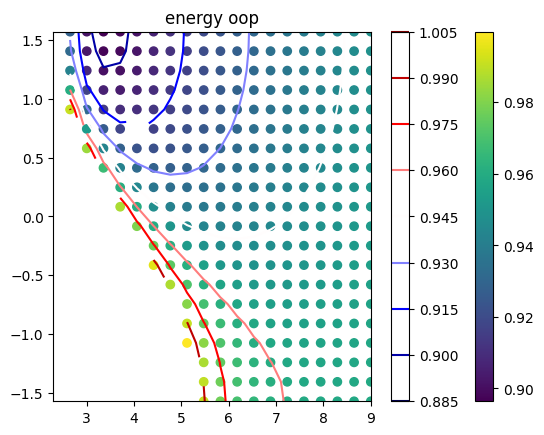

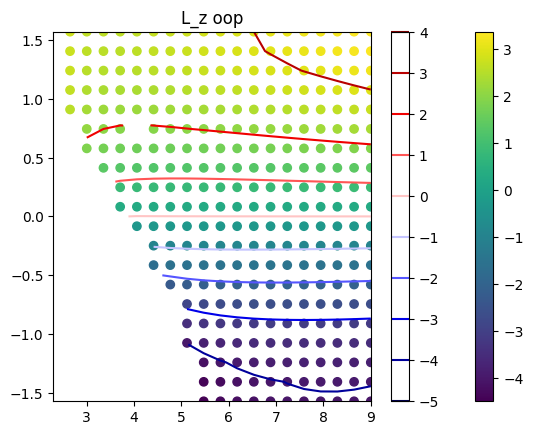

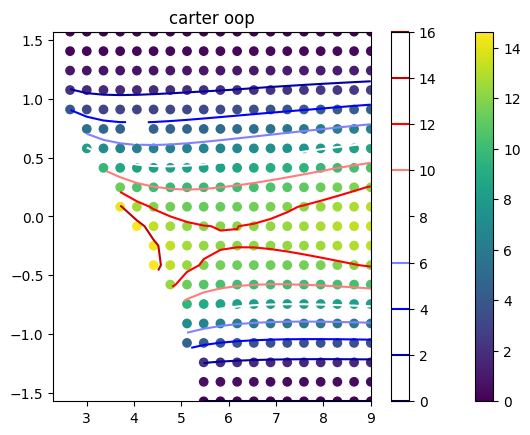

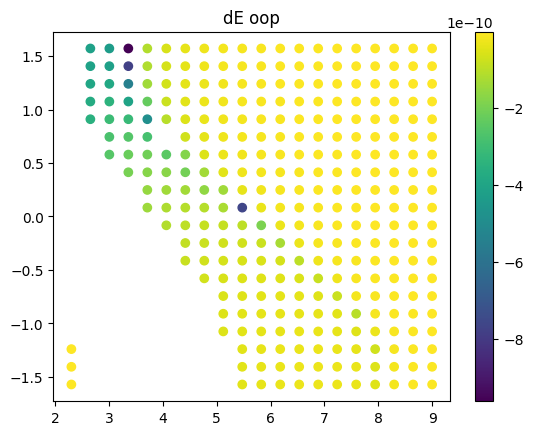

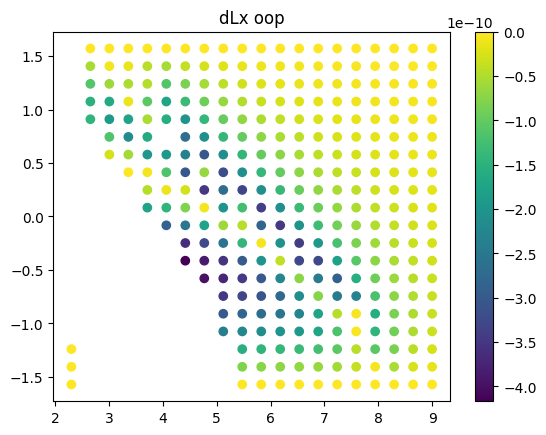

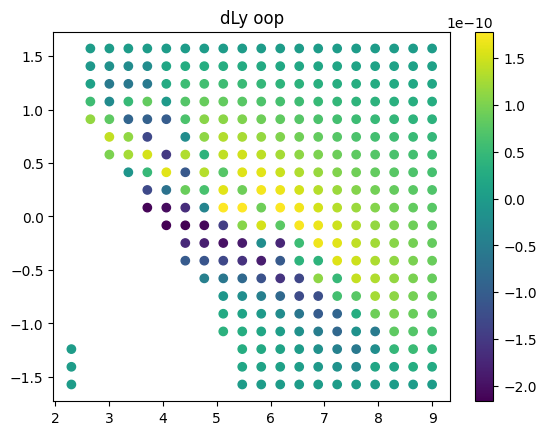

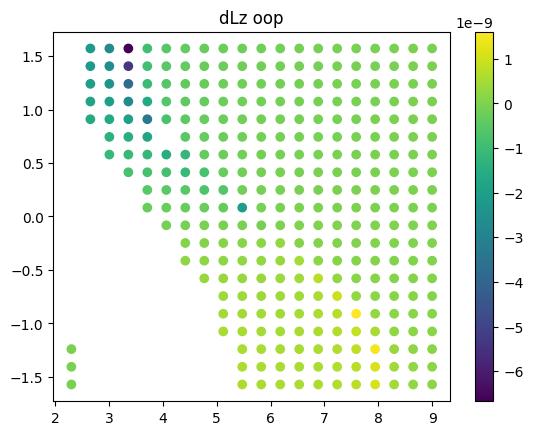

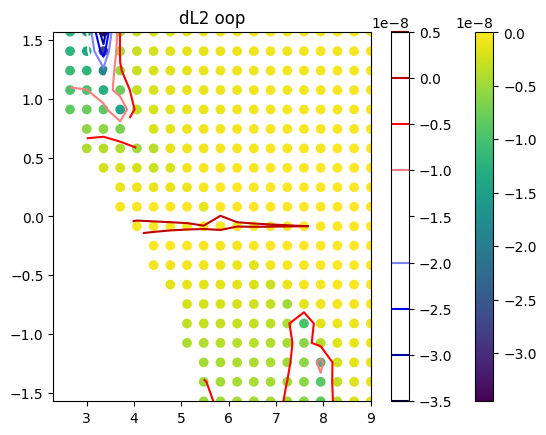

In [79]:
bound_ps = np.ones_like(incs)
for i in range(len(incs)):
    p_list, e_list, _ = mm.get_sep_inc(a, incs[i])
    bound_ps[i] = p_list[op.get_index(e_list, e)]/(1 + e)



mask = CONS[0] < 1
CONS2 = CONS.copy()
for i in range(3):
    CONS2[i] = np.where(mask, CONS[i], np.nan)

titles = ["energy", "L_z", "carter"]
for i in range(3):
    
    #plt.figure(figsize=(8,8))
    #plt.imshow(CONS2[i, :, :], extent=[ps[0], ps[-1], incs[0], incs[-1]], origin="lower")
    plt.scatter(PS, INCS, c=CONS2[i,:,:])
    plt.colorbar()
    plt.contour(PS, INCS, CONS2[i, :, :], cmap="seismic")
    plt.colorbar()
    #plt.axvline(4.825, c="k")
    #plt.axvline(6.785, c="k")
    #plt.axvline(8.5, c="k")
    #plt.plot(bound_ps, incs, c="k")
    plt.title(titles[i] + " oop")
    
    plt.show()

titles = ["dE", "dLx", "dLy", "dLz"]
for i in range(4):
    
    #plt.figure(figsize=(8,8))
    #plt.imshow(CONS[i, :, :], extent=[incs[0], incs[-1], ps[0], ps[-1]], origin="lower")
    plt.scatter(PS, INCS, c=DERVS[i,:,:])
    plt.colorbar()
    #plt.axvline(3.3931284701816304, c="k")
    #plt.axvline(8.142965464834315, c="k")
    #plt.axvline(4.825, c="k")
    #plt.axvline(6.785, c="k")
    #plt.axvline(8.5, c="k")
    #plt.plot(bound_ps, incs, c="k")
    #plt.contour(PS, INCS, DERVS[i, :, :], cmap="seismic")
    #plt.colorbar()
    plt.title(titles[i] + " oop")
    
    plt.show()

plt.scatter(PS, INCS, c=2 * DERVS[3,:,:] * CONS2[1,:,:])
plt.colorbar()
plt.contour(PS, INCS, 2 * DERVS[3,:,:] * CONS2[1,:,:], cmap="seismic")
plt.colorbar()
#plt.axvline(4.825, c="k")
#plt.axvline(6.785, c="k")
#plt.axvline(8.5, c="k")
#plt.plot(bound_ps, incs, c="k")
plt.title("dL2 oop")

plt.show()


In [ ]:
mm.find_rmb(0.1)

In [446]:
a, e = 0.9, 0.9
for v in list(big_dict[a, e]["Angular"][1].keys()):
    E, L, C = big_dict[a, e]["Angular"][1][v][1][:, 0], big_dict[a, e]["Angular"][1][v][1][:, 1], big_dict[a, e]["Angular"][1][v][1][:, 2]
    dE, dL = big_dict[a, e]["Angular"][1][v][1][:, 3], big_dict[a, e]["Angular"][1][v][1][:, 6]
    incs = big_dict[a, e]["Angular"][0]
    z = np.cos(incs)
    z2 = z * z
    x2 = 1 - z2
    x = np.sqrt(x2) * np.sign(L)
    a2 = a * a
    dC_dE = -2 * a2 * z2 * E
    dC_dL = 2 * z2 * L / (1 - z2)

    dC0 = dC_dE*dE + dC_dL*dL
    dx1 = dC0 + 2*(1 - x2)*a*a*E*dE - 2*L*dL*(1 - x2)/x2
    dx1 /= -2*(x*(a*a*(1 - E*E) + L*L/x2) + L*L*(1 - x2)/(x**3))

    dx1_2 = -(0.5*dC0*x2*x + a2*E*dE*x2*x*(1 - x2) - L*dL*x*(1 - x2))
    dx1_2 /= (a2*x2*x2*(1 - E*E) + L*L)

    hold = (1 - ((a2*(1 - (E + dE)**2) + (C + dC0) + (L + dL)**2) - np.sqrt((a2*(1 - (E + dE)**2) + (C + dC0) + (L + dL)**2)**2 - 4*a2*(1 - (E + dE)**2)*(C + dC0)))/(2 * a2*(1 - (E + dE)**2)))
    dx23_2 = -x + np.sign(x)*np.sqrt(hold)

    org = ((a2*(1 - E*E) + C + L*L) - np.sqrt((a2*(1 - E*E) + C + L*L)**2 - 4*a2*(1 - E*E)*C ))/(2 * a2*(1 - E*E))
    new = ((a2*(1 - (E + dE)**2) + (C + dC0) + (L + dL)**2) - np.sqrt((a2*(1 - (E + dE)**2) + (C + dC0) + (L + dL)**2)**2 - 4*a2*(1 - (E + dE)**2)*(C + dC0)))/(2 * a2*(1 - (E + dE)**2))
    Z = org - new
    dx45_2 = np.sign(L + dL)*np.sqrt(1 - new) - x
    
    print(f"{v: ^30}: {np.sqrt(np.nanmean(dx1**2)):.4e}, {np.sqrt(np.nanmean(dx1_2**2)):.4e}, {np.sqrt(np.nanmean(dx23_2**2)):.4e}, {np.sqrt(np.nanmean(dx45_2**2)):.4e}")

       Very Weak Field        : 8.8122e-31, 1.5791e-30, 2.2259e-11, 2.2259e-11
          Weak Field          : 6.1122e-30, 7.2384e-30, 1.7330e-12, 1.7330e-12
      Intermediate Field      : 1.1847e-28, 1.2307e-28, 3.8986e-13, 3.8986e-13
     Shallow Strong Field     : 8.6915e-28, 9.8118e-28, 1.1086e-13, 1.1086e-13
     Medium Strong Field      : 1.2160e-27, 1.6803e-27, 3.5270e-14, 3.5270e-14
      Deep Strong Field       : 5.9864e-27, 1.2224e-26, 6.0360e-15, 6.0360e-15


Shallow Strong Field: p = 8.5


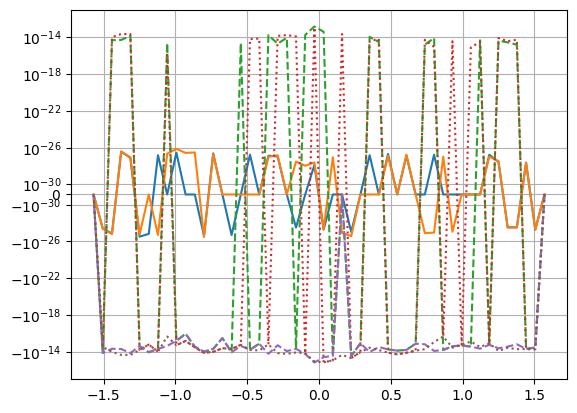

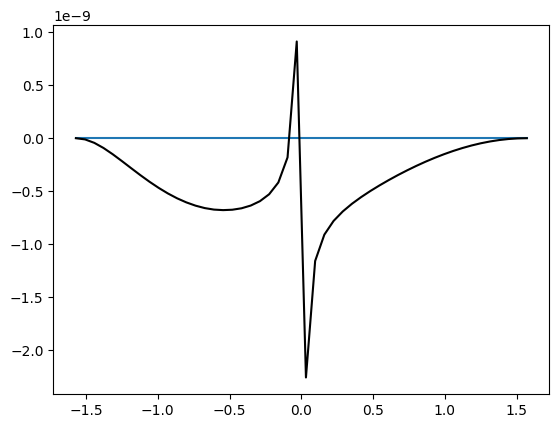

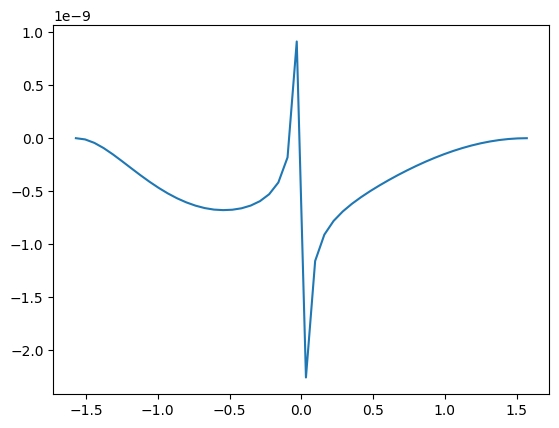

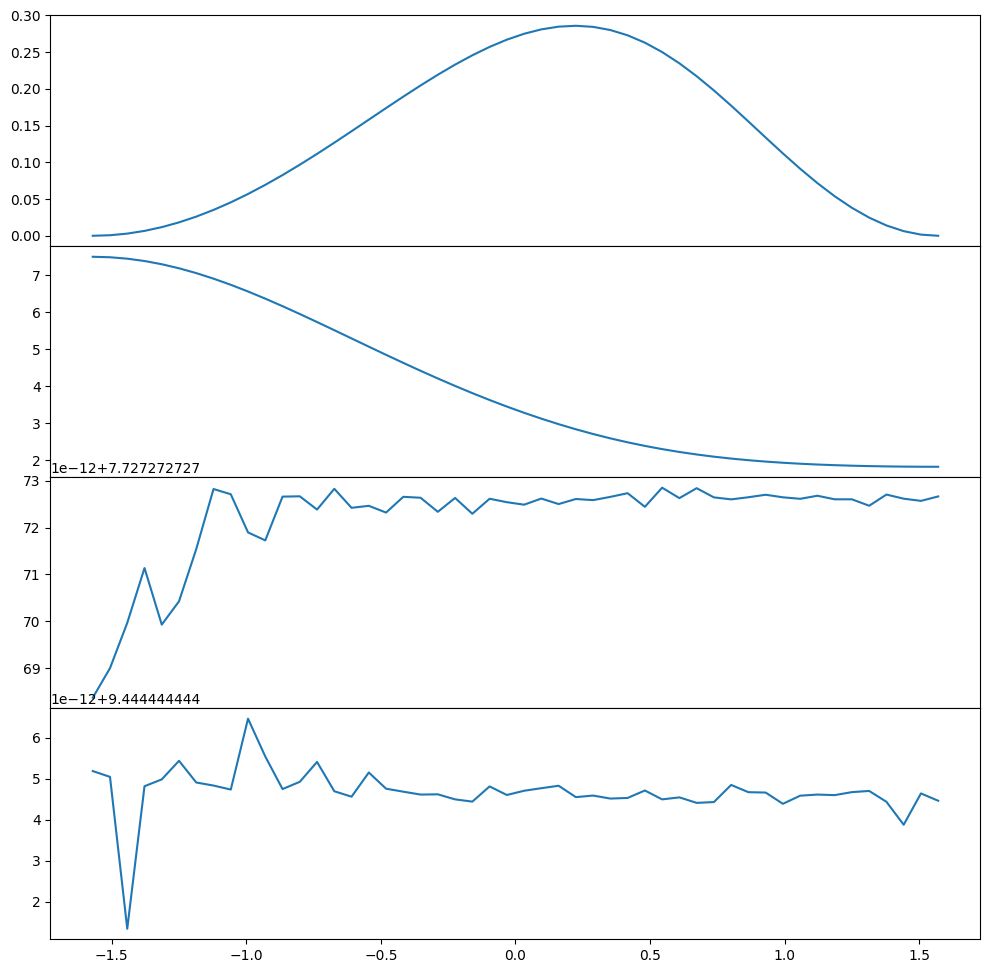

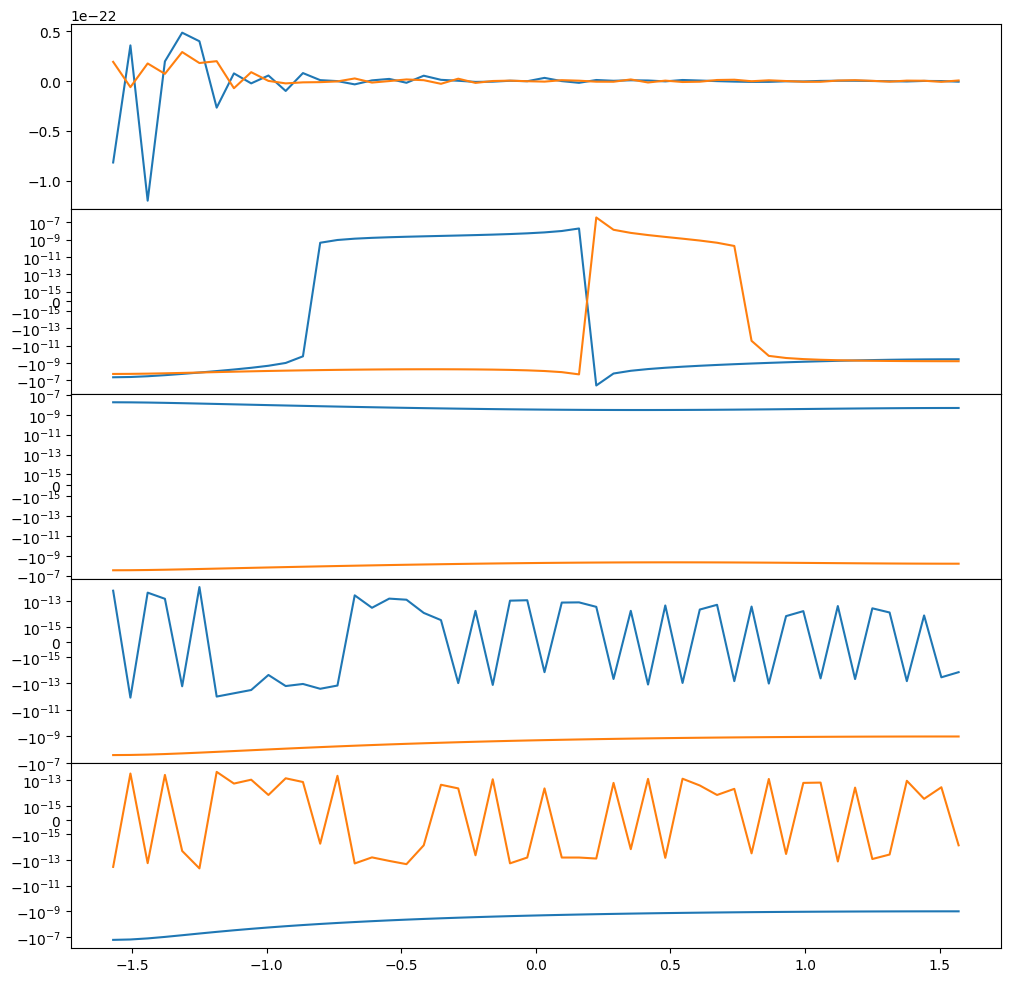

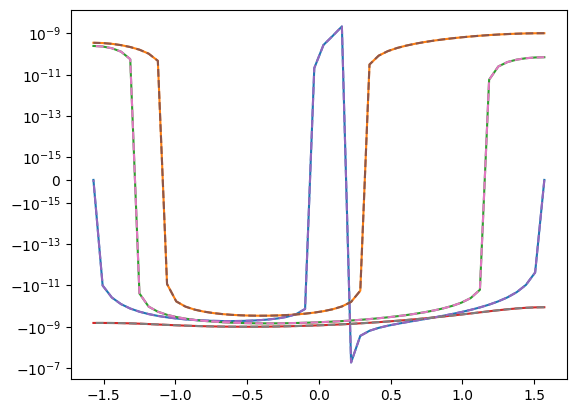

In [ ]:
a, e = 0.7, 0.1
v = np.random.choice(list(big_dict[a, e]["Angular"][1].keys()))
#v = "Deep Strong Field"
print(f"{v}: p = {big_dict[a, e]["Angular"][1][v][0]}")
E, L, C = big_dict[a, e]["Angular"][1][v][1][:, 0], big_dict[a, e]["Angular"][1][v][1][:, 1], big_dict[a, e]["Angular"][1][v][1][:, 2]
dE, dL = big_dict[a, e]["Angular"][1][v][1][:, 3], big_dict[a, e]["Angular"][1][v][1][:, 6]
incs = big_dict[a, e]["Angular"][0]
z = np.cos(incs)
z2 = z * z
x2 = 1 - z2
x = np.sqrt(x2) * np.sign(L)
a2 = a * a
dC_dE = -2 * a2 * z2 * E
dC_dL = 2 * z2 * L / (1 - z2)

dC0 = dC_dE*dE + dC_dL*dL
dx1 = dC0 + 2*(1 - x2)*a*a*E*dE - 2*L*dL*(1 - x2)/x2
dx1 /= -2*(x*(a*a*(1 - E*E) + L*L/x2) + L*L*(1 - x2)/(x**3))

dx1_2 = -(0.5*dC0*x2*x + a2*E*dE*x2*x*(1 - x2) - L*dL*x*(1 - x2))
dx1_2 /= (a2*x2*x2*(1 - E*E) + L*L)

hold = (1 - ((a2*(1 - (E + dE)**2) + (C + dC0) + (L + dL)**2) - np.sqrt((a2*(1 - (E + dE)**2) + (C + dC0) + (L + dL)**2)**2 - 4*a2*(1 - (E + dE)**2)*(C + dC0)))/(2 * a2*(1 - (E + dE)**2)))
dx2 = -x + np.sqrt(hold)
dx3 = -x - np.sqrt(hold)
dx23 = np.where(L >= 0, dx2, dx3)
dx23_2 = -x + np.sign(x)*np.sqrt(hold)


org = ((a2*(1 - E*E) + C + L*L) - np.sqrt((a2*(1 - E*E) + C + L*L)**2 - 4*a2*(1 - E*E)*C ))/(2 * a2*(1 - E*E))
new = ((a2*(1 - (E + dE)**2) + (C + dC0) + (L + dL)**2) - np.sqrt((a2*(1 - (E + dE)**2) + (C + dC0) + (L + dL)**2)**2 - 4*a2*(1 - (E + dE)**2)*(C + dC0)))/(2 * a2*(1 - (E + dE)**2))

Z = org - new
dx4 = -x + np.sqrt(x2 + Z)
dx5 = -x - np.sqrt(x2 + Z)
dx45 = np.where(L >= 0, dx4, dx5)
dx45_2 = -x + np.sign(x)*np.sqrt(x2 + Z)

plt.plot(incs, dx1)
plt.plot(incs, dx1_2)
#plt.plot(incs, a2*x2*x2*(1 - E*E) + L*L )
#plt.plot(incs, dx2, linestyle="--")
#plt.plot(incs, dx3, linestyle="-.")
#plt.plot(incs, dx4, linestyle=":")
#plt.plot(incs, dx5, linestyle=(0, (3, 5, 1, 5, 1, 5)))
#plt.plot(incs, dx23, linestyle=":")
plt.plot(incs, dx23_2, linestyle="--")
plt.plot(incs, dx45_2, linestyle=":")
#plt.plot(incs, Z)
#print(max(Z))
plt.plot(incs, -np.abs(dx23_2), linestyle="--")
plt.plot(incs, -np.abs(dx45_2), linestyle=":")
#plt.plot(incs, x2 - hold)
#plt.plot(incs, x2)
#plt.plot(incs, -x)
plt.yscale("symlog", linthresh=1e-30)
#plt.ylim(-1e-11, 1e-11)
plt.grid()
plt.show()

dC_dx = - 2*(a*a*x*(1 - E*E) + L*L/(x**3))

plt.plot(incs, dx1*dC_dx)
#plt.plot(incs, dx23 * dC_dx, linestyle="--")
#plt.plot(incs, dx45 * dC_dx, linestyle=":")
#plt.plot(incs, -np.abs(dx23) * dC_dx, linestyle="--")
#plt.plot(incs, -np.abs(dx45) * dC_dx, linestyle=":")
plt.plot(incs, dC0, color="k")
#plt.yscale("symlog", linthresh=1e-15)
plt.show()

plt.plot(incs, dx1*dC_dx + dC0)
#plt.plot(incs, dx23 * dC_dx + dC0, linestyle="--")
#plt.plot(incs, dx45 * dC_dx + dC0, linestyle=":")
#plt.plot(incs, -np.abs(dx23) * dC_dx + dC0, linestyle="--")
#plt.plot(incs, -np.abs(dx45) * dC_dx + dC0, linestyle=":")
#plt.plot(incs, dC0, color="k")
#plt.yscale("symlog", linthresh=1e-15)
plt.show()

poly = np.array([(E**2 - 1), 2*np.ones_like(E), ((a**2)*(E**2 - 1) - L**2 - C), 2*((a*E - L)**2 + C), -C*(a**2)]).T
roots = []
for subpoly in poly:
    if True in np.isnan(subpoly):
        roots.append(np.nan*np.arange(4))
    else:
        roots.append(np.sort(np.roots(subpoly)))
roots = np.array(roots)
r = roots
E_r, L_r, C_r = np.vstack([E for i in range(len(r[0]))]).T, np.vstack([L for i in range(len(r[0]))]).T, np.vstack([C for i in range(len(r[0]))]).T
dE_r, dL_r = np.vstack([dE for i in range(len(r[0]))]).T, np.vstack([dL for i in range(len(r[0]))]).T
P, D = E_r*(r*r + a*a) - a*L_r, r*r - 2*r + a*a
dC_dE_r = 2*P*(r*r + a*a)/D - 2*a*(a*E_r - L_r)
dC_dL_r = -2*a*P/D + 2*(a*E_r - L_r)
dC0_r = dC_dE_r*dE_r + dC_dL_r*dL_r
dC_dr = (4*E_r*r*P - P*P*(2*r - 2))/(D*D) - 2*r
dr = (2*E_r*dE_r*r*r*r*r + (2*a2*E_r*dE_r - 2*L_r*dL_r - dC0_r)*r*r + 2 * (2*(a*E_r - L_r)*(a*dE_r - dL_r) + dC0_r)*r - a2*dC0_r)/(4*(E_r*E_r - 1)*r*r*r + 6*r*r + 2*(a2*(E_r*E_r - 1) - L_r*L_r - C_r)*r + 2*((a*E_r - L_r)**2 + C_r))
poly2 = np.array([((E_r + dE_r)**2 - 1), 2*np.ones_like(E_r + dE_r), ((a**2)*((E_r + dE_r)**2 - 1) - (L_r + dL_r)**2 - (C_r + dC0_r)), 2*((a*(E_r + dE_r) - (L_r + dL_r))**2 + (C_r + dC0_r)), -(C_r + dC0_r)*(a**2)]).T

roots2 = []
for subset in poly2:
    roots2.append([])
    for subpoly in subset:
        if True in np.isnan(subpoly):
            roots2[-1].append(np.nan*np.arange(4))
        else:
            roots2[-1].append(np.sort(np.roots(subpoly)))
roots2 = np.array(roots2)
dr2 = roots2.copy()
for i in range(4):
    dr2[i] = dr2[i] - roots

fig, ax = plt.subplots(4, 1, sharex=True, gridspec_kw={"hspace":0}, figsize=(12,12))
[ax[i].plot(incs, r[:,i]) for i in range(4)]
plt.show()

fig, ax = plt.subplots(5, 1, sharex=True, gridspec_kw={"hspace":0}, figsize=(12,12))
ax[0].plot(incs, dr[:,-2:])
[ax[i+1].plot(incs, dr2[i][:, -2:]) for i in range(4)]
[ax[i+1].set_yscale("symlog", linthresh=1e-15) for i in range(4)]
plt.show()

plt.plot(incs, dC0_r)
plt.plot(incs, dC0_r + dC_dr*dr, linestyle="--")
plt.yscale("symlog", linthresh=1e-15)

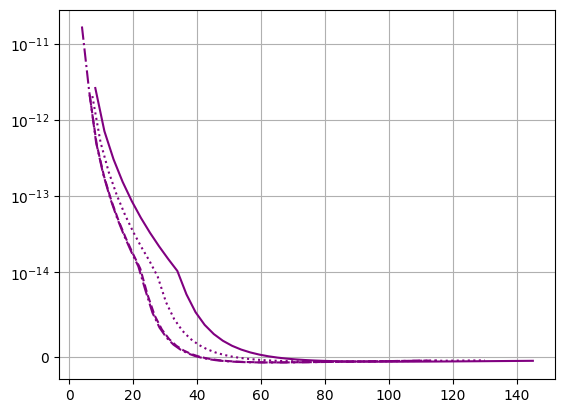

In [485]:
cols = {0.1: "red", 0.3: "orange", 0.5: "green", 0.7: "blue", 0.9: "purple"}
lnsty = {0.9: "solid", 0.5: "dotted", 0.1: "dashed", 1e-4: "dashdot"}
for a in [0.9]:#, 0.3, 0.5, 0.7, 0.9]:
    for e in [0.9, 0.5, 0.1, 1e-4]:
        key = (a, e)
        tilt = "Retrograde Near Polar"
        rs = big_dict[key]["Radial"][0]
        dL2 = 2 * big_dict[key]["Radial"][1][tilt][1][:, 1] * big_dict[key]["Radial"][1][tilt][1][:, 6]
        plt.plot(rs, dL2, c=cols[a], linestyle=lnsty[e])
        #print(f"{str(key): ^15}: Min = {np.nanmin(dL2):.7e}, Max = {np.nanmax(dL2):.7e}")
        #print(f"{"hey":@^10}")
plt.yscale("symlog", linthresh=1e-14)
plt.grid()

116.0
58.0
17.4
8.2
6.52
4.6


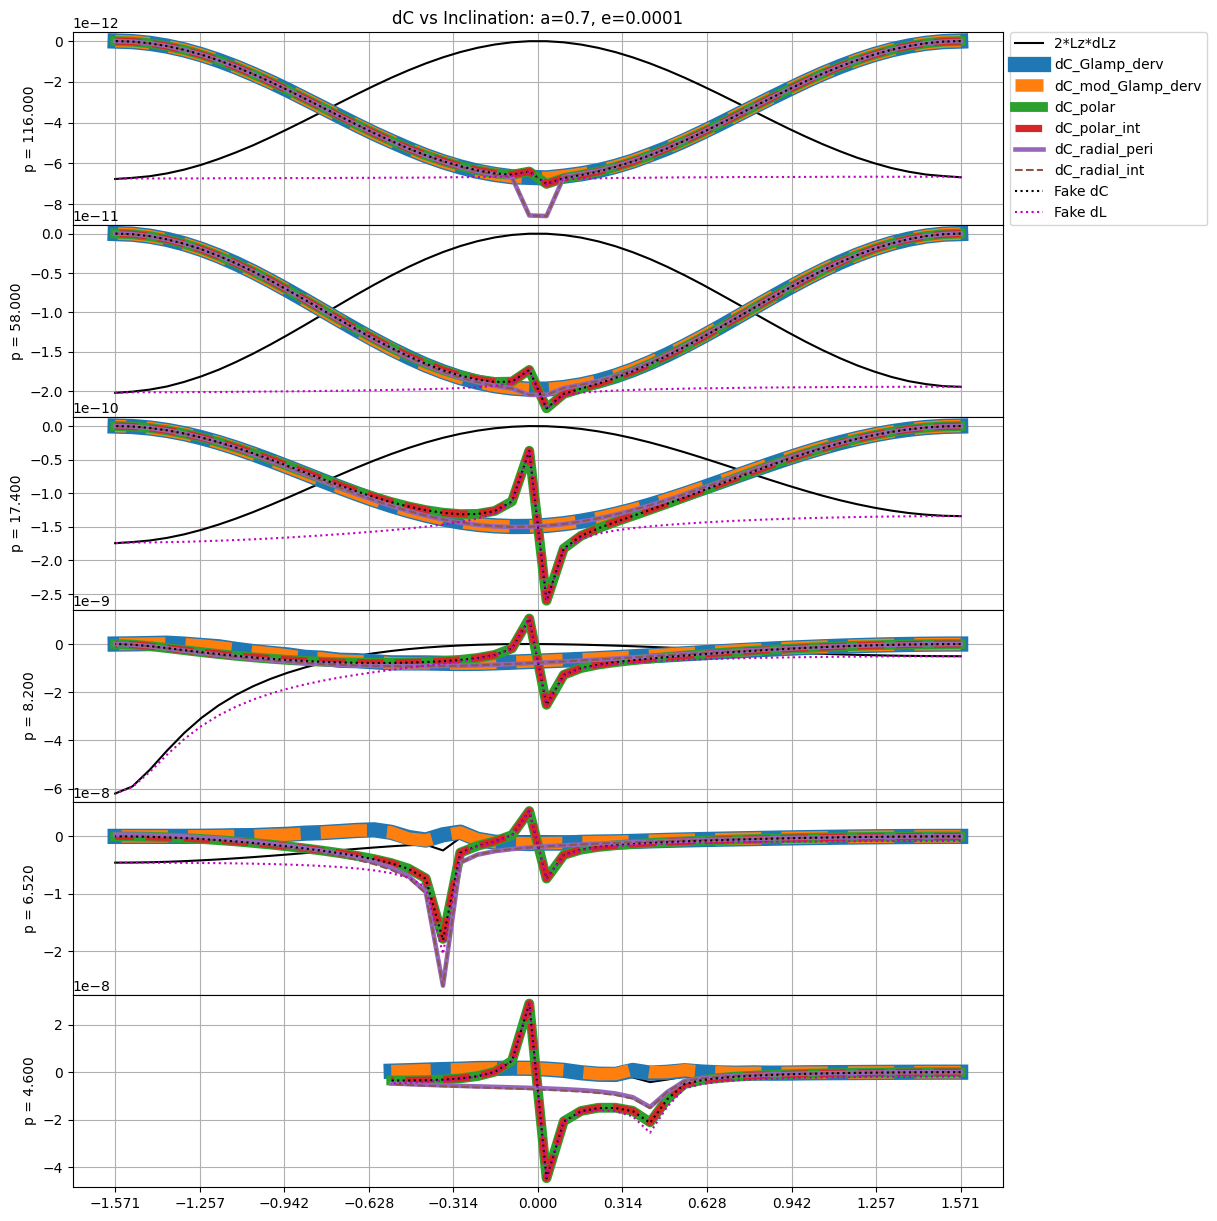

116.0
58.0
17.4
8.2
6.52
4.6


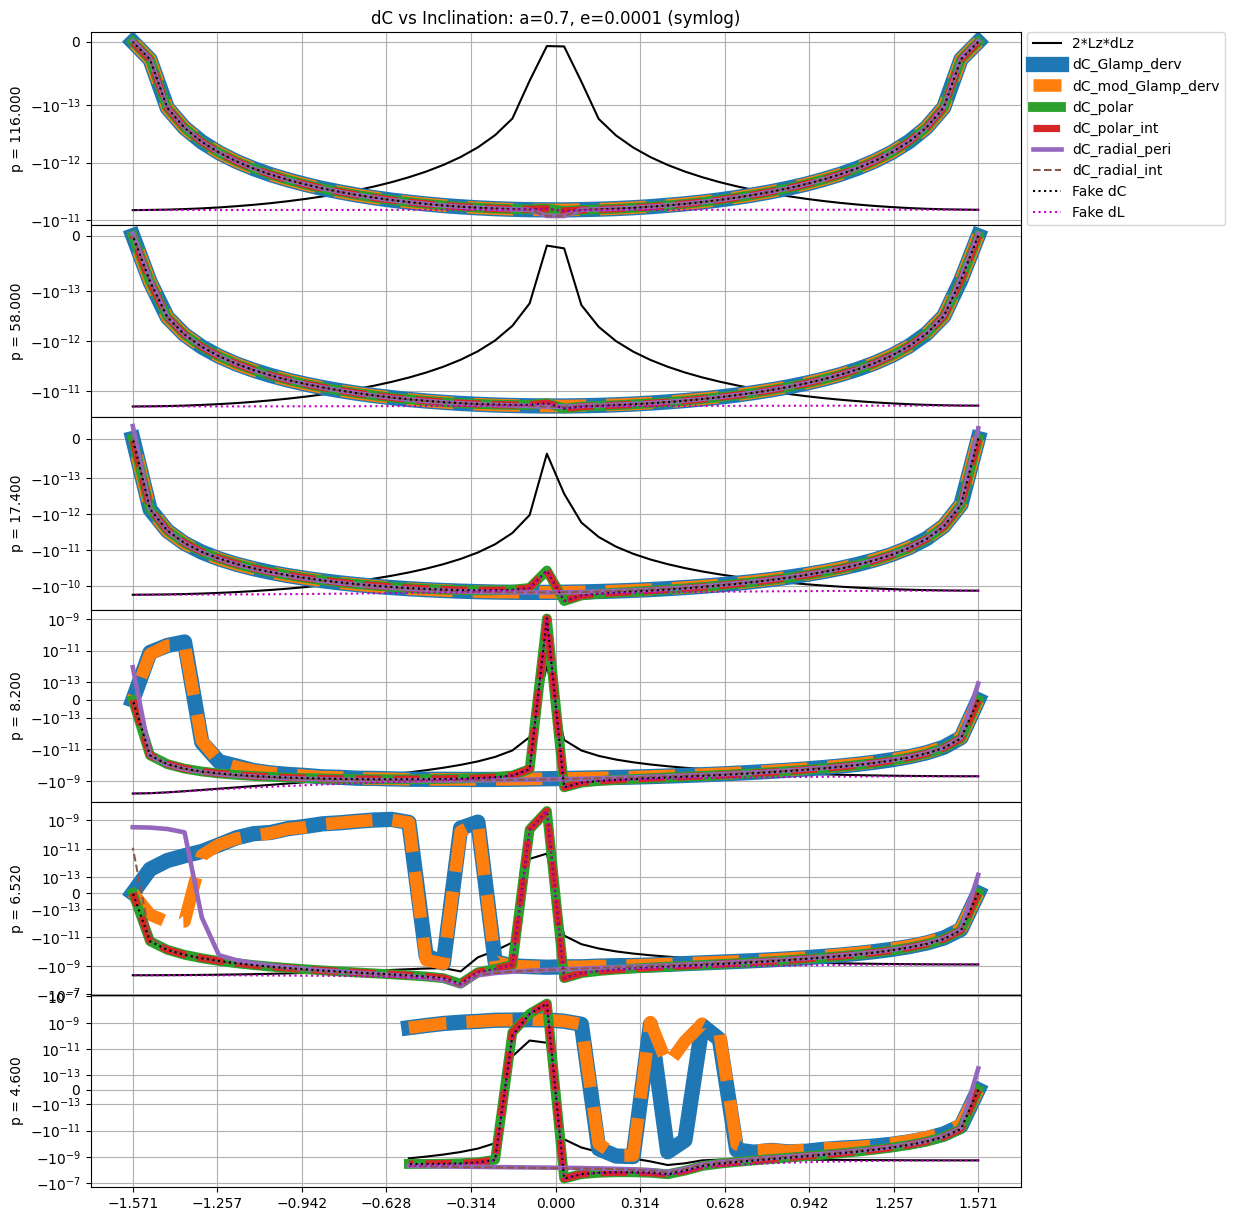

1.5707963267948966
0.7853981633974483
0.008726646259971648
-0.008726646259971648
-0.7853981633974483
-1.5707963267948966


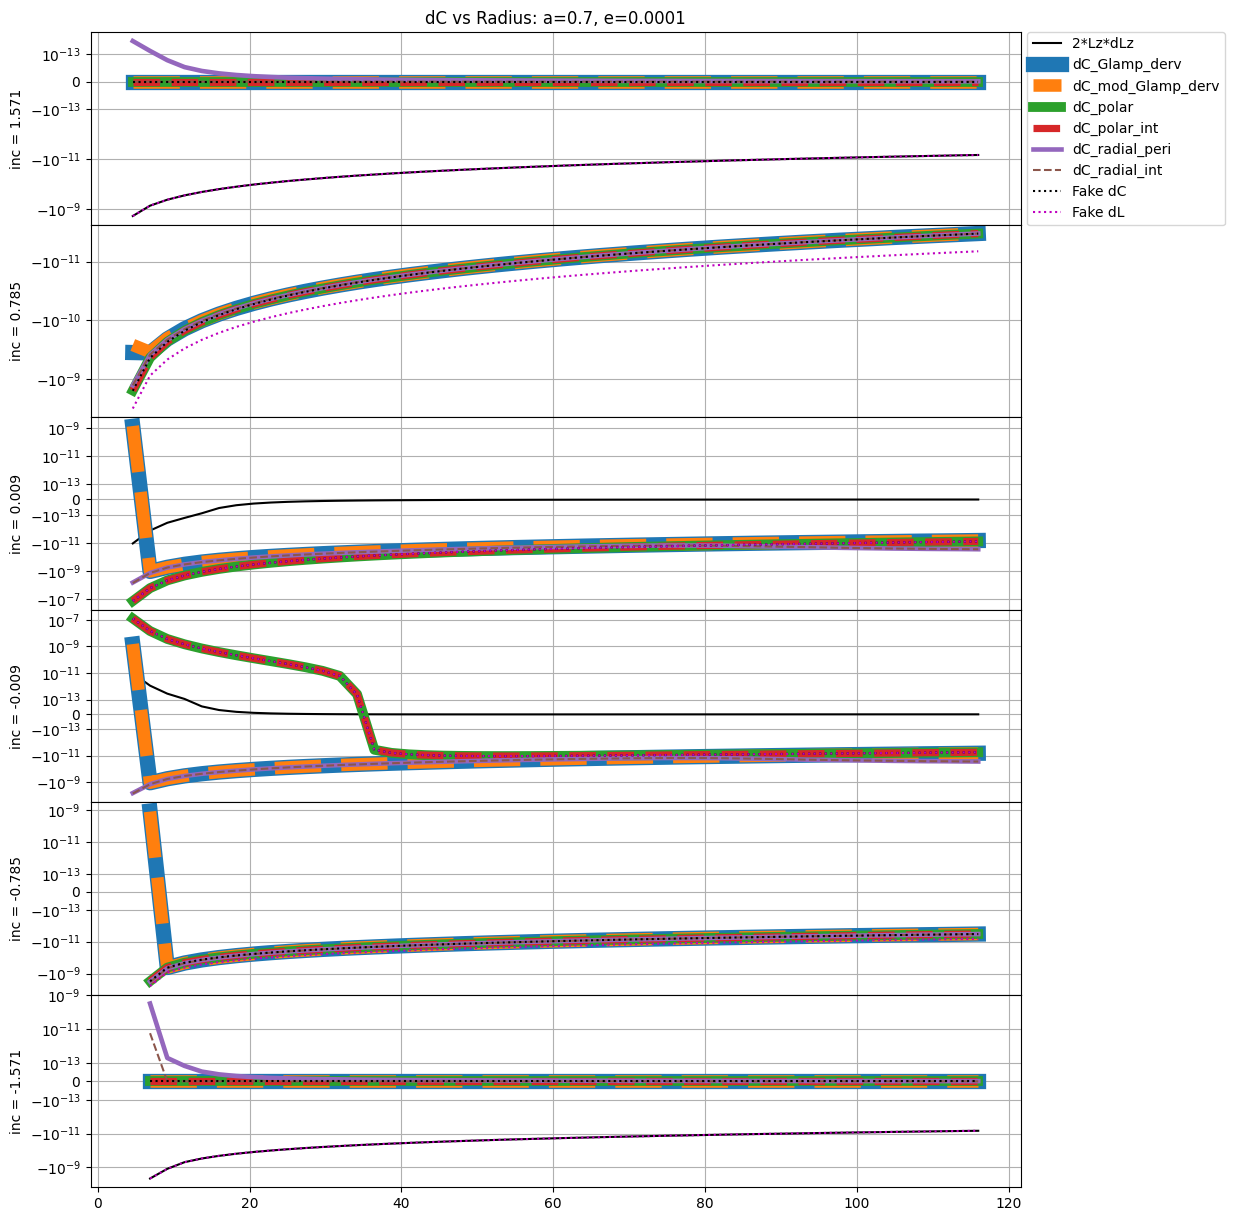

1.5707963267948966
0.7853981633974483
0.008726646259971648
-0.008726646259971648
-0.7853981633974483
-1.5707963267948966


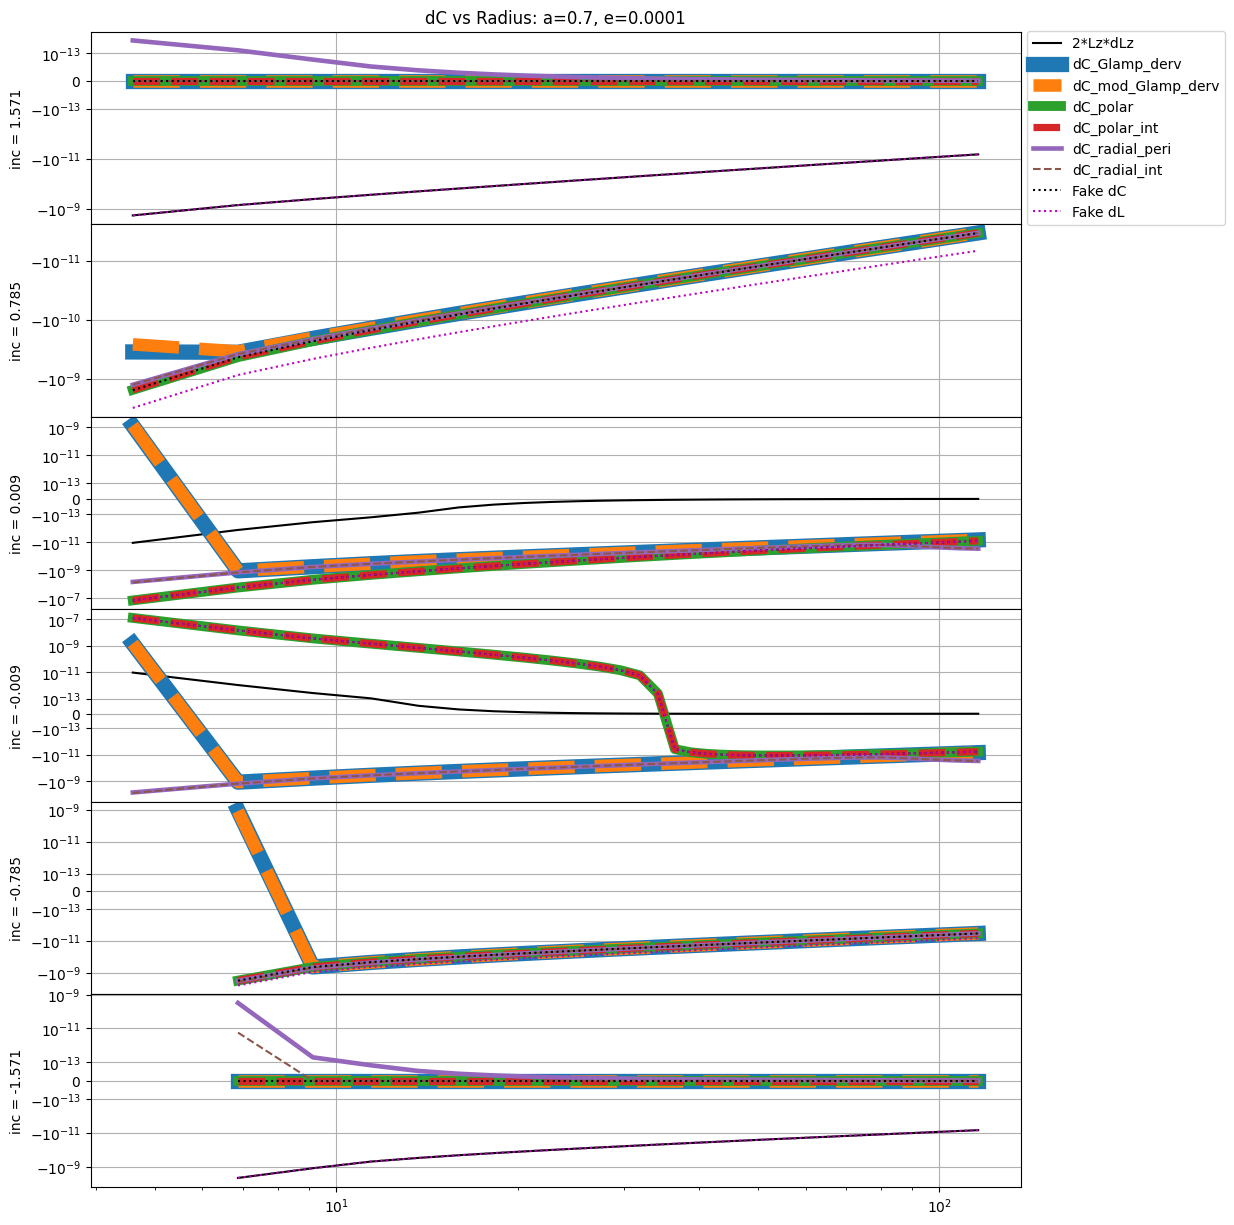

In [75]:
#print(big_dict[0.1, 0.1]["Angular"][1]["Very Weak Field"][1][:, 7])

a, e = 0.7, 1e-4
ix_labs = ["E0", "L0", "C0",                 # initial constants (0-2)
           "dE", "dLx", "dLy", "dLz",          # changes calculated from Peters (1964)  (3 - 6)
           "dC_least_squares",           # 7
           "dC_mod_least_squares",       # 8
           "dC_Glamp_derv",              # 9
           "dC_mod_Glamp_derv",          # 10
           "dC_polar",                   # 11
           "dC_polar_diff",              # 12
           "dC_polar_int",               # 13
           "dC_radial_pot_min",          # 14
           "dC_radial_apo",              # 15
           "dC_radial_peri",             # 16
           "dC_radial_semilat",          # 17
           "dC_radial_int"]              # 18

ixs = [9, 10, 11, 13, 16, 18]
lw = len(ixs) * 2 - 1
fig, ax = plt.subplots(len(list(big_dict[a, e]["Angular"][1].keys())), 1, sharex=True, figsize=((12, 15)), gridspec_kw={"hspace":0})
i = 0
ax[0].set_title(f"dC vs Inclination: a={a}, e={e}")
for v in big_dict[a, e]["Angular"][1].keys():
    print(big_dict[a, e]["Angular"][1][v][0])
    ax[i].plot(big_dict[a, e]["Angular"][0], 2 * big_dict[a, e]["Angular"][1][v][1][:, 1] * big_dict[a, e]["Angular"][1][v][1][:, 6], label="2*Lz*dLz", c="k")
    for j in range(len(ixs)):
        if j%2 == 0:
            ax[i].plot(big_dict[a, e]["Angular"][0], big_dict[a, e]["Angular"][1][v][1][:, ixs[j]], label=ix_labs[ixs[j]], linewidth = lw - 2*j*(0.99**j))
        else:
            ax[i].plot(big_dict[a, e]["Angular"][0], big_dict[a, e]["Angular"][1][v][1][:, ixs[j]], label=ix_labs[ixs[j]], linestyle="--", linewidth= lw - 2*j*(0.99**j))
    ax[i].plot(big_dict[a, e]["Angular"][0], 2 * big_dict[a, e]["Angular"][1][v][1][:, 1] * big_dict[a, e]["Angular"][1][v][1][:, 6] * (np.cos(big_dict[a, e]["Angular"][0])/np.sin(big_dict[a, e]["Angular"][0]))**2, label="Fake dC", c="k", linestyle=":")
    ax[i].plot(big_dict[a, e]["Angular"][0], 2 * big_dict[a, e]["Angular"][1][v][1][:, 1] * big_dict[a, e]["Angular"][1][v][1][:, 6] * (1/np.sin(big_dict[a, e]["Angular"][0]))**2, label="Fake dL", c="m", linestyle=":")
    ax[i].set_ylabel(f"p = {big_dict[a, e]["Angular"][1][v][0]:.3f}")
    ax[i].grid()
    if i == 0:
        ax[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    i += 1
plt.xticks(np.linspace(-np.pi/2, np.pi/2, 11))
plt.show()

fig, ax = plt.subplots(len(list(big_dict[a, e]["Angular"][1].keys())), 1, sharex=True, figsize=((12, 15)), gridspec_kw={"hspace":0})
i = 0
ax[0].set_title(f"dC vs Inclination: a={a}, e={e} (symlog)")
for v in big_dict[a, e]["Angular"][1].keys():
    print(big_dict[a, e]["Angular"][1][v][0])
    ax[i].plot(big_dict[a, e]["Angular"][0], 2 * big_dict[a, e]["Angular"][1][v][1][:, 1] * big_dict[a, e]["Angular"][1][v][1][:, 6], label="2*Lz*dLz", c="k")
    for j in range(len(ixs)):
        if j%2 == 0:
            ax[i].plot(big_dict[a, e]["Angular"][0], big_dict[a, e]["Angular"][1][v][1][:, ixs[j]], label=ix_labs[ixs[j]], linewidth= lw - 2*j*(0.99**j))
        else:
            ax[i].plot(big_dict[a, e]["Angular"][0], big_dict[a, e]["Angular"][1][v][1][:, ixs[j]], label=ix_labs[ixs[j]], linestyle="--", linewidth= lw - 2*j*(0.99**j))
    ax[i].plot(big_dict[a, e]["Angular"][0], 2 * big_dict[a, e]["Angular"][1][v][1][:, 1] * big_dict[a, e]["Angular"][1][v][1][:, 6] * (np.cos(big_dict[a, e]["Angular"][0])/np.sin(big_dict[a, e]["Angular"][0]))**2, label="Fake dC", c="k", linestyle=":")
    ax[i].plot(big_dict[a, e]["Angular"][0], 2 * big_dict[a, e]["Angular"][1][v][1][:, 1] * big_dict[a, e]["Angular"][1][v][1][:, 6] * (1/np.sin(big_dict[a, e]["Angular"][0]))**2, label="Fake dL", c="m", linestyle=":")
    #ax[i].set_xlim(-1.05*np.pi/2, 1.05*np.pi/2)
    ax[i].set_yscale("symlog", linthresh=1e-13)
    ax[i].set_ylabel(f"p = {big_dict[a, e]["Angular"][1][v][0]:.3f}")
    ax[i].grid()
    if i == 0:
        ax[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    i += 1
plt.xticks(np.linspace(-np.pi/2, np.pi/2, 11))
plt.show()

fig, ax = plt.subplots(len(list(big_dict[a, e]["Radial"][1].keys())), 1, sharex=True, figsize=((12, 15)), gridspec_kw={"hspace":0})
i = 0
ax[0].set_title(f"dC vs Radius: a={a}, e={e}")
for v in big_dict[a, e]["Radial"][1].keys():
    print(big_dict[a, e]["Radial"][1][v][0])
    ax[i].plot(big_dict[a, e]["Radial"][0], 2 * big_dict[a, e]["Radial"][1][v][1][:, 1] * big_dict[a, e]["Radial"][1][v][1][:, 6], label="2*Lz*dLz", c="k")
    for j in range(len(ixs)):
        if j%2 == 0:
            ax[i].plot(big_dict[a, e]["Radial"][0], big_dict[a, e]["Radial"][1][v][1][:, ixs[j]], label=ix_labs[ixs[j]], linewidth= lw - 2*j*(0.99**j))
        else:
            ax[i].plot(big_dict[a, e]["Radial"][0], big_dict[a, e]["Radial"][1][v][1][:, ixs[j]], label=ix_labs[ixs[j]], linestyle="--", linewidth= lw - 2*j*(0.99**j))
    ax[i].plot(big_dict[a, e]["Radial"][0], 2 * big_dict[a, e]["Radial"][1][v][1][:, 1] * big_dict[a, e]["Radial"][1][v][1][:, 6] * (np.cos(big_dict[a, e]["Radial"][1][v][0])/np.sin(big_dict[a, e]["Radial"][1][v][0]))**2, label="Fake dC", c="k", linestyle=":")
    ax[i].plot(big_dict[a, e]["Radial"][0], 2 * big_dict[a, e]["Radial"][1][v][1][:, 1] * big_dict[a, e]["Radial"][1][v][1][:, 6] * (1/np.sin(big_dict[a, e]["Radial"][1][v][0]))**2, label="Fake dL", c="m", linestyle=":")
    ax[i].set_ylabel(f"inc = {big_dict[a, e]["Radial"][1][v][0]:.3f}")
    ax[i].set_yscale("symlog", linthresh=1e-13)
    ax[i].grid()
    if i == 0:
        ax[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    i += 1
plt.show()

fig, ax = plt.subplots(len(list(big_dict[a, e]["Radial"][1].keys())), 1, sharex=True, figsize=((12, 15)), gridspec_kw={"hspace":0})
i = 0
ax[0].set_title(f"dC vs Radius: a={a}, e={e}")
for v in big_dict[a, e]["Radial"][1].keys():
    print(big_dict[a, e]["Radial"][1][v][0])
    ax[i].plot(big_dict[a, e]["Radial"][0], 2 * big_dict[a, e]["Radial"][1][v][1][:, 1] * big_dict[a, e]["Radial"][1][v][1][:, 6], label="2*Lz*dLz", c="k")
    for j in range(len(ixs)):
        if j%2 == 0:
            ax[i].plot(big_dict[a, e]["Radial"][0], big_dict[a, e]["Radial"][1][v][1][:, ixs[j]], label=ix_labs[ixs[j]], linewidth= lw - 2*j*(0.99**j))
        else:
            ax[i].plot(big_dict[a, e]["Radial"][0], big_dict[a, e]["Radial"][1][v][1][:, ixs[j]], label=ix_labs[ixs[j]], linestyle="--", linewidth= lw - 2*j*(0.99**j))
    ax[i].plot(big_dict[a, e]["Radial"][0], 2 * big_dict[a, e]["Radial"][1][v][1][:, 1] * big_dict[a, e]["Radial"][1][v][1][:, 6] * (np.cos(big_dict[a, e]["Radial"][1][v][0])/np.sin(big_dict[a, e]["Radial"][1][v][0]))**2, label="Fake dC", c="k", linestyle=":")
    ax[i].plot(big_dict[a, e]["Radial"][0], 2 * big_dict[a, e]["Radial"][1][v][1][:, 1] * big_dict[a, e]["Radial"][1][v][1][:, 6] * (1/np.sin(big_dict[a, e]["Radial"][1][v][0]))**2, label="Fake dL", c="m", linestyle=":")
    ax[i].set_ylabel(f"inc = {big_dict[a, e]["Radial"][1][v][0]:.3f}")
    ax[i].set_yscale("symlog", linthresh=1e-13)
    ax[i].set_xscale("log")
    ax[i].grid()
    if i == 0:
        ax[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    i += 1
plt.show()